In [1]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
rootDir = '/kaggle/input/indoor-scenes-cvpr-2019/indoorCVPR_09/Images'

allData = []
for label in sorted(os.listdir(rootDir)):
    labelDir = os.path.join(rootDir, label)
    if os.path.isdir(labelDir):
        for file in os.listdir(labelDir):
            if file.lower().endswith(('.jpg', '.jpeg', '.png')):
                imgPath = os.path.join(labelDir, file)
                allData.append((imgPath, label))

# 80-10-10 stratified split
trainData, tempData = train_test_split(
    allData, test_size=0.2, stratify=[label for _, label in allData], random_state=42
)
valData, testData = train_test_split(
    tempData, test_size=0.5, stratify=[label for _, label in tempData], random_state=42
)

labelNames = sorted(set([label for _, label in allData]))
labelToIndex = {label: idx for idx, label in enumerate(labelNames)}
classNames = labelNames

print(f"Loaded: Train = {len(trainData)}, Val = {len(valData)}, Test = {len(testData)}")


Loaded: Train = 12496, Val = 1562, Test = 1562


In [3]:

mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]
trainTransform = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    transforms.RandomAffine(degrees=15, shear=10),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])





class SceneDataset(Dataset):
    def __init__(self, data, transform=None):
        self.data = data
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        imgPath, label = self.data[idx]
        image = Image.open(imgPath).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, labelToIndex[label]



Class Distribution in Train Set:
airport_inside      : 486
artstudio           : 112
auditorium          : 141
bakery              : 324
bar                 : 483
bathroom            : 158
bedroom             : 530
bookstore           : 304
bowling             : 170
buffet              : 89
casino              : 412
children_room       : 90
church_inside       : 144
classroom           : 90
cloister            : 96
closet              : 108
clothingstore       : 85
computerroom        : 91
concert_hall        : 82
corridor            : 277
deli                : 206
dentaloffice        : 105
dining_room         : 219
elevator            : 81
fastfood_restaurant : 93
florist             : 82
gameroom            : 102
garage              : 82
greenhouse          : 81
grocerystore        : 170
gym                 : 185
hairsalon           : 191
hospitalroom        : 81
inside_bus          : 82
inside_subway       : 366
jewelleryshop       : 126
kindergarden        : 102
kitchen           

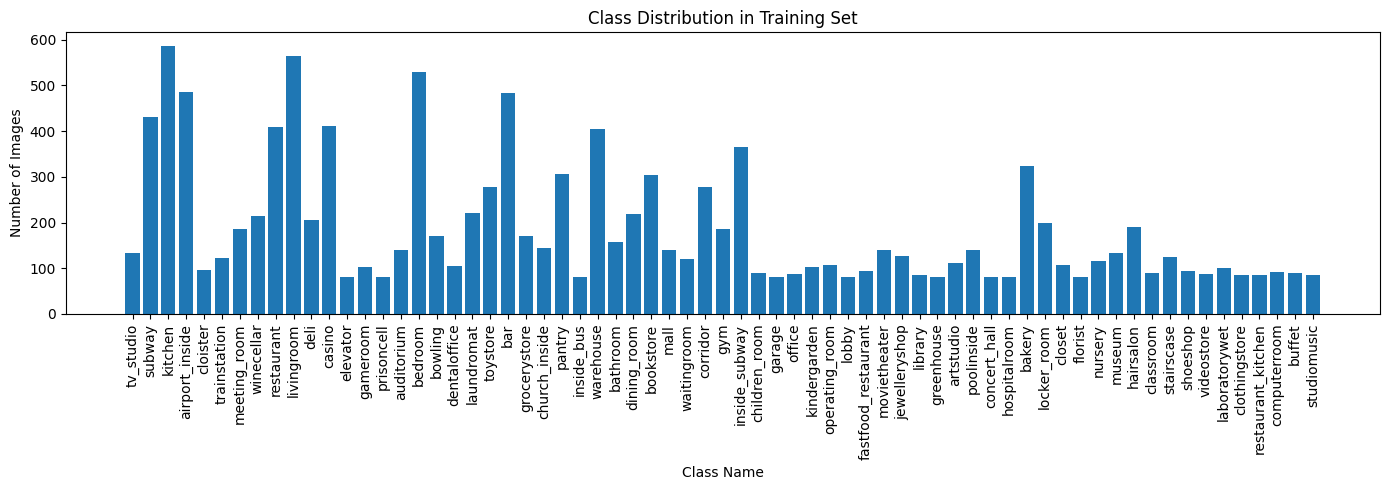

In [4]:
from collections import Counter
import matplotlib.pyplot as plt

# Count training samples per class
trainLabels = [label for _, label in trainData]
labelCounts = Counter(trainLabels)

# Print counts
print("\nClass Distribution in Train Set:")
for cls in sorted(labelCounts):
    print(f"{cls:20s}: {labelCounts[cls]}")

# Optional: plot class distribution
plt.figure(figsize=(14, 5))
plt.bar(labelCounts.keys(), labelCounts.values())
plt.xticks(rotation=90)
plt.title("Class Distribution in Training Set")
plt.xlabel("Class Name")
plt.ylabel("Number of Images")
plt.tight_layout()
plt.show()


In [5]:
batchSize = 64

trainDataset = SceneDataset(trainData, trainTransform)
valDataset = SceneDataset(valData, transform)
testDataset = SceneDataset(testData, transform)

trainLoader = DataLoader(trainDataset, batch_size=batchSize, shuffle=True)
valLoader = DataLoader(valDataset, batch_size=batchSize, shuffle=False)
testLoader = DataLoader(testDataset, batch_size=batchSize, shuffle=False)

classNames = labelNames


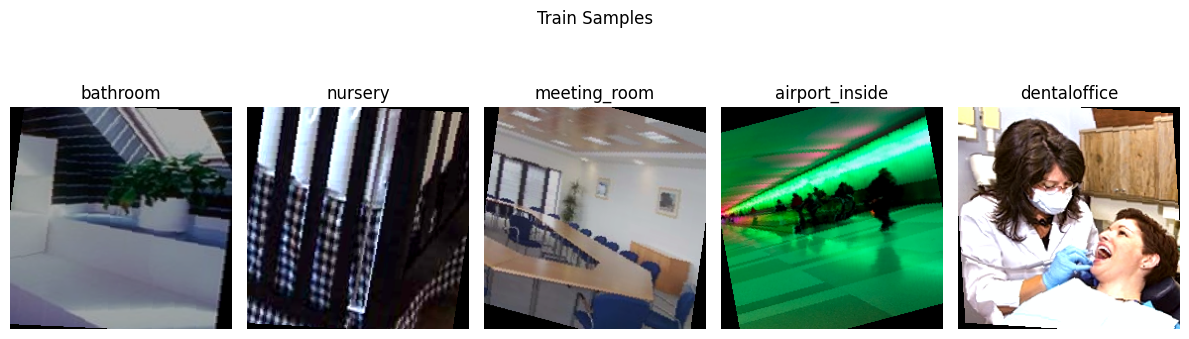

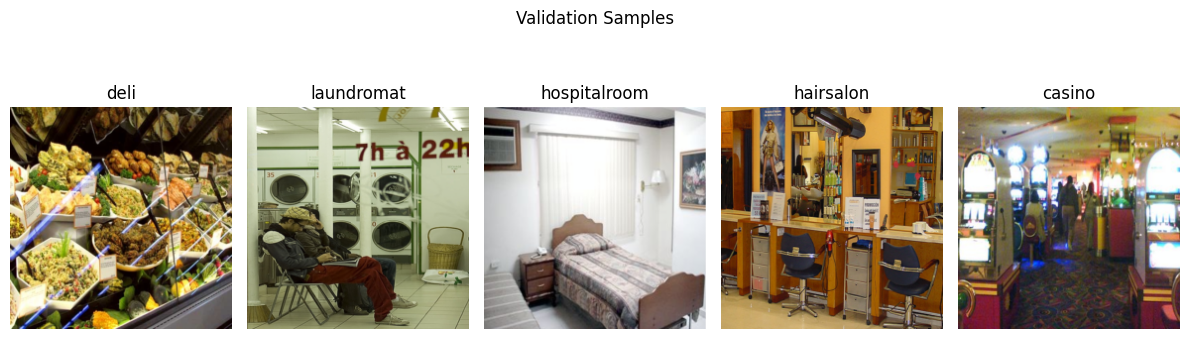

In [6]:

def showSamples(dataLoader, classNames, title="Sample Images"):
    images, labels = next(iter(dataLoader))
    plt.figure(figsize=(12, 4))
    for i in range(5):
        img = images[i].permute(1, 2, 0).numpy()  # Convert CHW → HWC
        img = img * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])  # Unnormalize
        img = np.clip(img, 0, 1)
        plt.subplot(1, 5, i+1)
        plt.imshow(img)
        plt.title(classNames[labels[i].item()])
        plt.axis('off')
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

showSamples(trainLoader, classNames, title="Train Samples")
showSamples(valLoader, classNames, title="Validation Samples")


In [7]:
import torch
import torch.nn as nn

# Dense Layer
class DenseLayer(nn.Module):
    def __init__(self, in_channels, growth_rate):
        super(DenseLayer, self).__init__()
        self.bn = nn.BatchNorm2d(in_channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv = nn.Conv2d(in_channels, growth_rate, kernel_size=3, padding=1, bias=False)

    def forward(self, x):
        out = self.conv(self.relu(self.bn(x)))
        return torch.cat([x, out], 1)  # Dense connection

# Dense Block
class DenseBlock(nn.Module):
    def __init__(self, num_layers, in_channels, growth_rate):
        super(DenseBlock, self).__init__()
        layers = []
        for i in range(num_layers):
            layers.append(DenseLayer(in_channels + i * growth_rate, growth_rate))
        self.block = nn.Sequential(*layers)

    def forward(self, x):
        return self.block(x)

# Transition Layer
class TransitionLayer(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(TransitionLayer, self).__init__()
        self.layer = nn.Sequential(
            nn.BatchNorm2d(in_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False),
            nn.AvgPool2d(2)
        )

    def forward(self, x):
        return self.layer(x)

#Full DenseNet
class DenseNetLikeSceneClassifier(nn.Module):
    def __init__(self, growth_rate=32, block_layers=[4, 6, 8], num_classes=67):
        super(DenseNetLikeSceneClassifier, self).__init__()

        # Initial Conv Layer
        self.stem = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False),  # Conv
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(3, stride=2, padding=1)  # Pool
        )

        # Dense Blocks + Transitions
        self.features = nn.Sequential()
        num_channels = 64
        for i, num_layers in enumerate(block_layers):
            block = DenseBlock(num_layers, num_channels, growth_rate)
            self.features.add_module(f'denseblock{i+1}', block)
            num_channels = num_channels + num_layers * growth_rate
            if i != len(block_layers) - 1:  # no transition after last block
                trans = TransitionLayer(num_channels, num_channels // 2)
                self.features.add_module(f'transition{i+1}', trans)
                num_channels = num_channels // 2

        # Final batch norm
        self.bn_final = nn.BatchNorm2d(num_channels)

        # Classifier head
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Linear(num_channels, num_classes)
        )

    def forward(self, x):
        x = self.stem(x)
        x = self.features(x)
        x = self.bn_final(x)
        x = self.classifier(x)
        return x


In [8]:
from torchinfo import summary

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = DenseNetLikeSceneClassifier(
    growth_rate=32,
    block_layers=[4, 6, 8],
    num_classes=67
).to(device)



summary(model, input_size=(1, 3, 224, 224))


Layer (type:depth-idx)                        Output Shape              Param #
DenseNetLikeSceneClassifier                   [1, 67]                   --
├─Sequential: 1-1                             [1, 64, 56, 56]           --
│    └─Conv2d: 2-1                            [1, 64, 112, 112]         9,408
│    └─BatchNorm2d: 2-2                       [1, 64, 112, 112]         128
│    └─ReLU: 2-3                              [1, 64, 112, 112]         --
│    └─MaxPool2d: 2-4                         [1, 64, 56, 56]           --
├─Sequential: 1-2                             [1, 400, 14, 14]          --
│    └─DenseBlock: 2-5                        [1, 192, 56, 56]          --
│    │    └─Sequential: 3-1                   [1, 192, 56, 56]          129,920
│    └─TransitionLayer: 2-6                   [1, 96, 28, 28]           --
│    │    └─Sequential: 3-2                   [1, 96, 28, 28]           18,816
│    └─DenseBlock: 2-7                        [1, 288, 28, 28]          --
│    │ 

In [9]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
import torch

trainEncodedLabels = [labelToIndex[label] for _, label in trainData]  # Or however you store them

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(trainEncodedLabels),
    y=trainEncodedLabels
)

class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)


In [10]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = DenseNetLikeSceneClassifier(
    growth_rate=32,
    block_layers=[6, 12, 24, 16],
    num_classes=67
).to(device)

# Use weighted cross entropy loss
criterion = nn.CrossEntropyLoss(
    weight=class_weights,
    label_smoothing=0.1  # Keep this to help with noisy labels
)

# Optimizer and scheduler
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-4, weight_decay=5e-5)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=120)
earlyStopPatience = 15
batchSize = 64


In [11]:
import time

def trainModel(model, trainLoader, valLoader, criterion, optimizer, scheduler, epochs=120, earlyStopPatience=5):
    bestValAcc = 0
    patienceCounter = 0

    trainAccList, valAccList, trainLossList, valLossList = [], [], [], []

    for epoch in range(epochs):
        start_time = time.time()

        model.train()
        totalTrainLoss, correctTrain, totalTrain = 0, 0, 0

        for images, labels in trainLoader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            totalTrainLoss += loss.item()
            _, preds = outputs.max(1)
            correctTrain += (preds == labels).sum().item()
            totalTrain += labels.size(0)

        trainAcc = correctTrain / totalTrain
        trainLoss = totalTrainLoss / len(trainLoader)

        valLoss, valAcc = evaluateModel(model, valLoader, criterion)

        trainAccList.append(trainAcc)
        valAccList.append(valAcc)
        trainLossList.append(trainLoss)
        valLossList.append(valLoss)

        scheduler.step()

        elapsed_time = time.time() - start_time
        print(f"Current LR: {scheduler.get_last_lr()[0]:.6f}")
        print(f"Epoch {epoch+1:02d} | Train Acc: {trainAcc:.4f} | Val Acc: {valAcc:.4f} | "
              f"Train Loss: {trainLoss:.4f} | Val Loss: {valLoss:.4f} | Time: {elapsed_time:.2f}s")

        if valAcc > bestValAcc:
            bestValAcc = valAcc
            patienceCounter = 0
            torch.save(model.state_dict(), "bestModel.pth")
        else:
            patienceCounter += 1
            if patienceCounter >= earlyStopPatience:
                print("Early stopping triggered.")
                break

    return trainAccList, valAccList, trainLossList, valLossList


In [12]:

def evaluateModel(model, dataLoader, criterion):
    model.eval()
    totalLoss, correct, total = 0.0, 0, 0

    with torch.no_grad():
        for images, labels in dataLoader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            totalLoss += loss.item()
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    avgLoss = totalLoss / len(dataLoader)
    accuracy = correct / total
    return avgLoss, accuracy

In [13]:
trainAccList, valAccList, trainLossList, valLossList = trainModel(
    model, trainLoader, valLoader, criterion, optimizer, scheduler,
    epochs=120, earlyStopPatience=earlyStopPatience
)


Current LR: 0.000200
Epoch 01 | Train Acc: 0.0450 | Val Acc: 0.0787 | Train Loss: 4.2170 | Val Loss: 4.0324 | Time: 322.67s
Current LR: 0.000200
Epoch 02 | Train Acc: 0.0883 | Val Acc: 0.1236 | Train Loss: 3.9953 | Val Loss: 3.8545 | Time: 244.50s
Current LR: 0.000200
Epoch 03 | Train Acc: 0.1102 | Val Acc: 0.1460 | Train Loss: 3.8578 | Val Loss: 3.6955 | Time: 255.23s
Current LR: 0.000199
Epoch 04 | Train Acc: 0.1236 | Val Acc: 0.1364 | Train Loss: 3.7838 | Val Loss: 3.6822 | Time: 247.68s
Current LR: 0.000199
Epoch 05 | Train Acc: 0.1470 | Val Acc: 0.1588 | Train Loss: 3.6921 | Val Loss: 3.7212 | Time: 248.66s
Current LR: 0.000199
Epoch 06 | Train Acc: 0.1647 | Val Acc: 0.2042 | Train Loss: 3.6395 | Val Loss: 3.4728 | Time: 251.26s
Current LR: 0.000198
Epoch 07 | Train Acc: 0.1788 | Val Acc: 0.1946 | Train Loss: 3.5475 | Val Loss: 3.4663 | Time: 249.73s
Current LR: 0.000198
Epoch 08 | Train Acc: 0.2001 | Val Acc: 0.2407 | Train Loss: 3.4852 | Val Loss: 3.3492 | Time: 250.49s
Current 

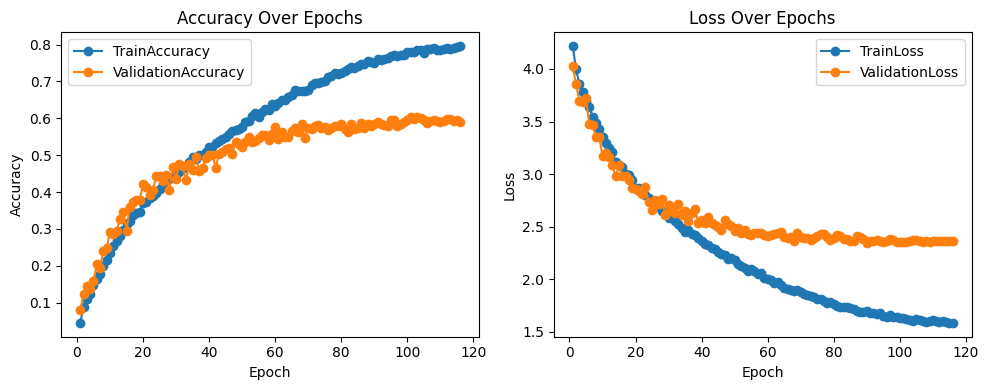

In [14]:
import matplotlib.pyplot as plt

def plotAccuracyLoss(trainAccList, valAccList, trainLossList, valLossList):
    Epochs = range(1, len(trainAccList) + 1)

    # Accuracy Plot
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.plot(Epochs, trainAccList, label='TrainAccuracy', marker='o')
    plt.plot(Epochs, valAccList, label='ValidationAccuracy', marker='o')
    plt.title('Accuracy Over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    # Loss Plot
    plt.subplot(1, 2, 2)
    plt.plot(Epochs, trainLossList, label='TrainLoss', marker='o')
    plt.plot(Epochs, valLossList, label='ValidationLoss', marker='o')
    plt.title('Loss Over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.tight_layout()
    plt.show()

plotAccuracyLoss(trainAccList, valAccList, trainLossList, valLossList)


In [15]:
model.load_state_dict(torch.load("bestModel.pth"))
testLoss, testAcc = evaluateModel(model, testLoader, criterion)
print(f"Test Accuracy: {testAcc*100:.4f} Test Loss: {testLoss:.4f}")

Test Accuracy: 62.0999 Test Loss: 2.2637


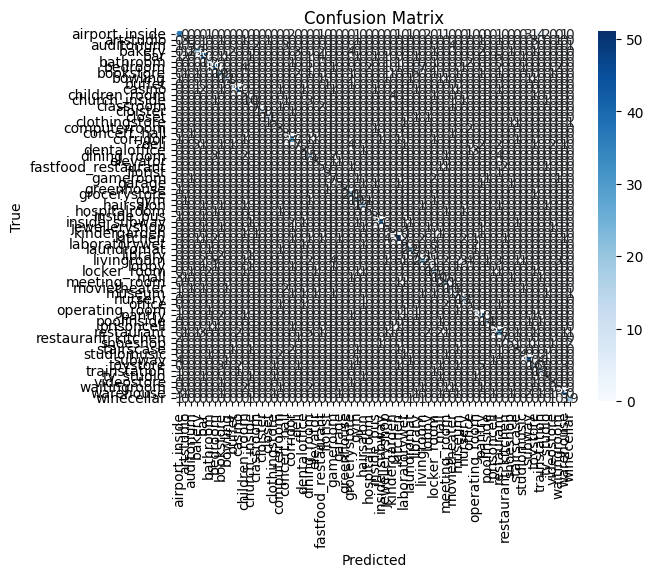

                     precision    recall  f1-score   support

     airport_inside       0.60      0.61      0.60        61
          artstudio       0.27      0.21      0.24        14
         auditorium       0.50      0.29      0.37        17
             bakery       0.73      0.54      0.62        41
                bar       0.68      0.64      0.66        61
           bathroom       0.58      0.55      0.56        20
            bedroom       0.66      0.59      0.62        66
          bookstore       0.56      0.50      0.53        38
            bowling       0.80      0.55      0.65        22
             buffet       0.67      0.73      0.70        11
             casino       0.89      0.76      0.82        51
      children_room       0.25      0.45      0.32        11
      church_inside       0.59      0.56      0.57        18
          classroom       0.70      0.64      0.67        11
           cloister       1.00      0.92      0.96        12
             closet    

In [16]:
allLabels, allPreds = [], []
model.eval()
with torch.no_grad():
    for images, labels in testLoader:
        images = images.to(device)
        outputs = model(images)
        _, preds = outputs.max(1)
        allLabels.extend(labels.cpu().numpy())
        allPreds.extend(preds.cpu().numpy())

cm = confusion_matrix(allLabels, allPreds)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=classNames, yticklabels=classNames, cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

print(classification_report(allLabels, allPreds, target_names=classNames))


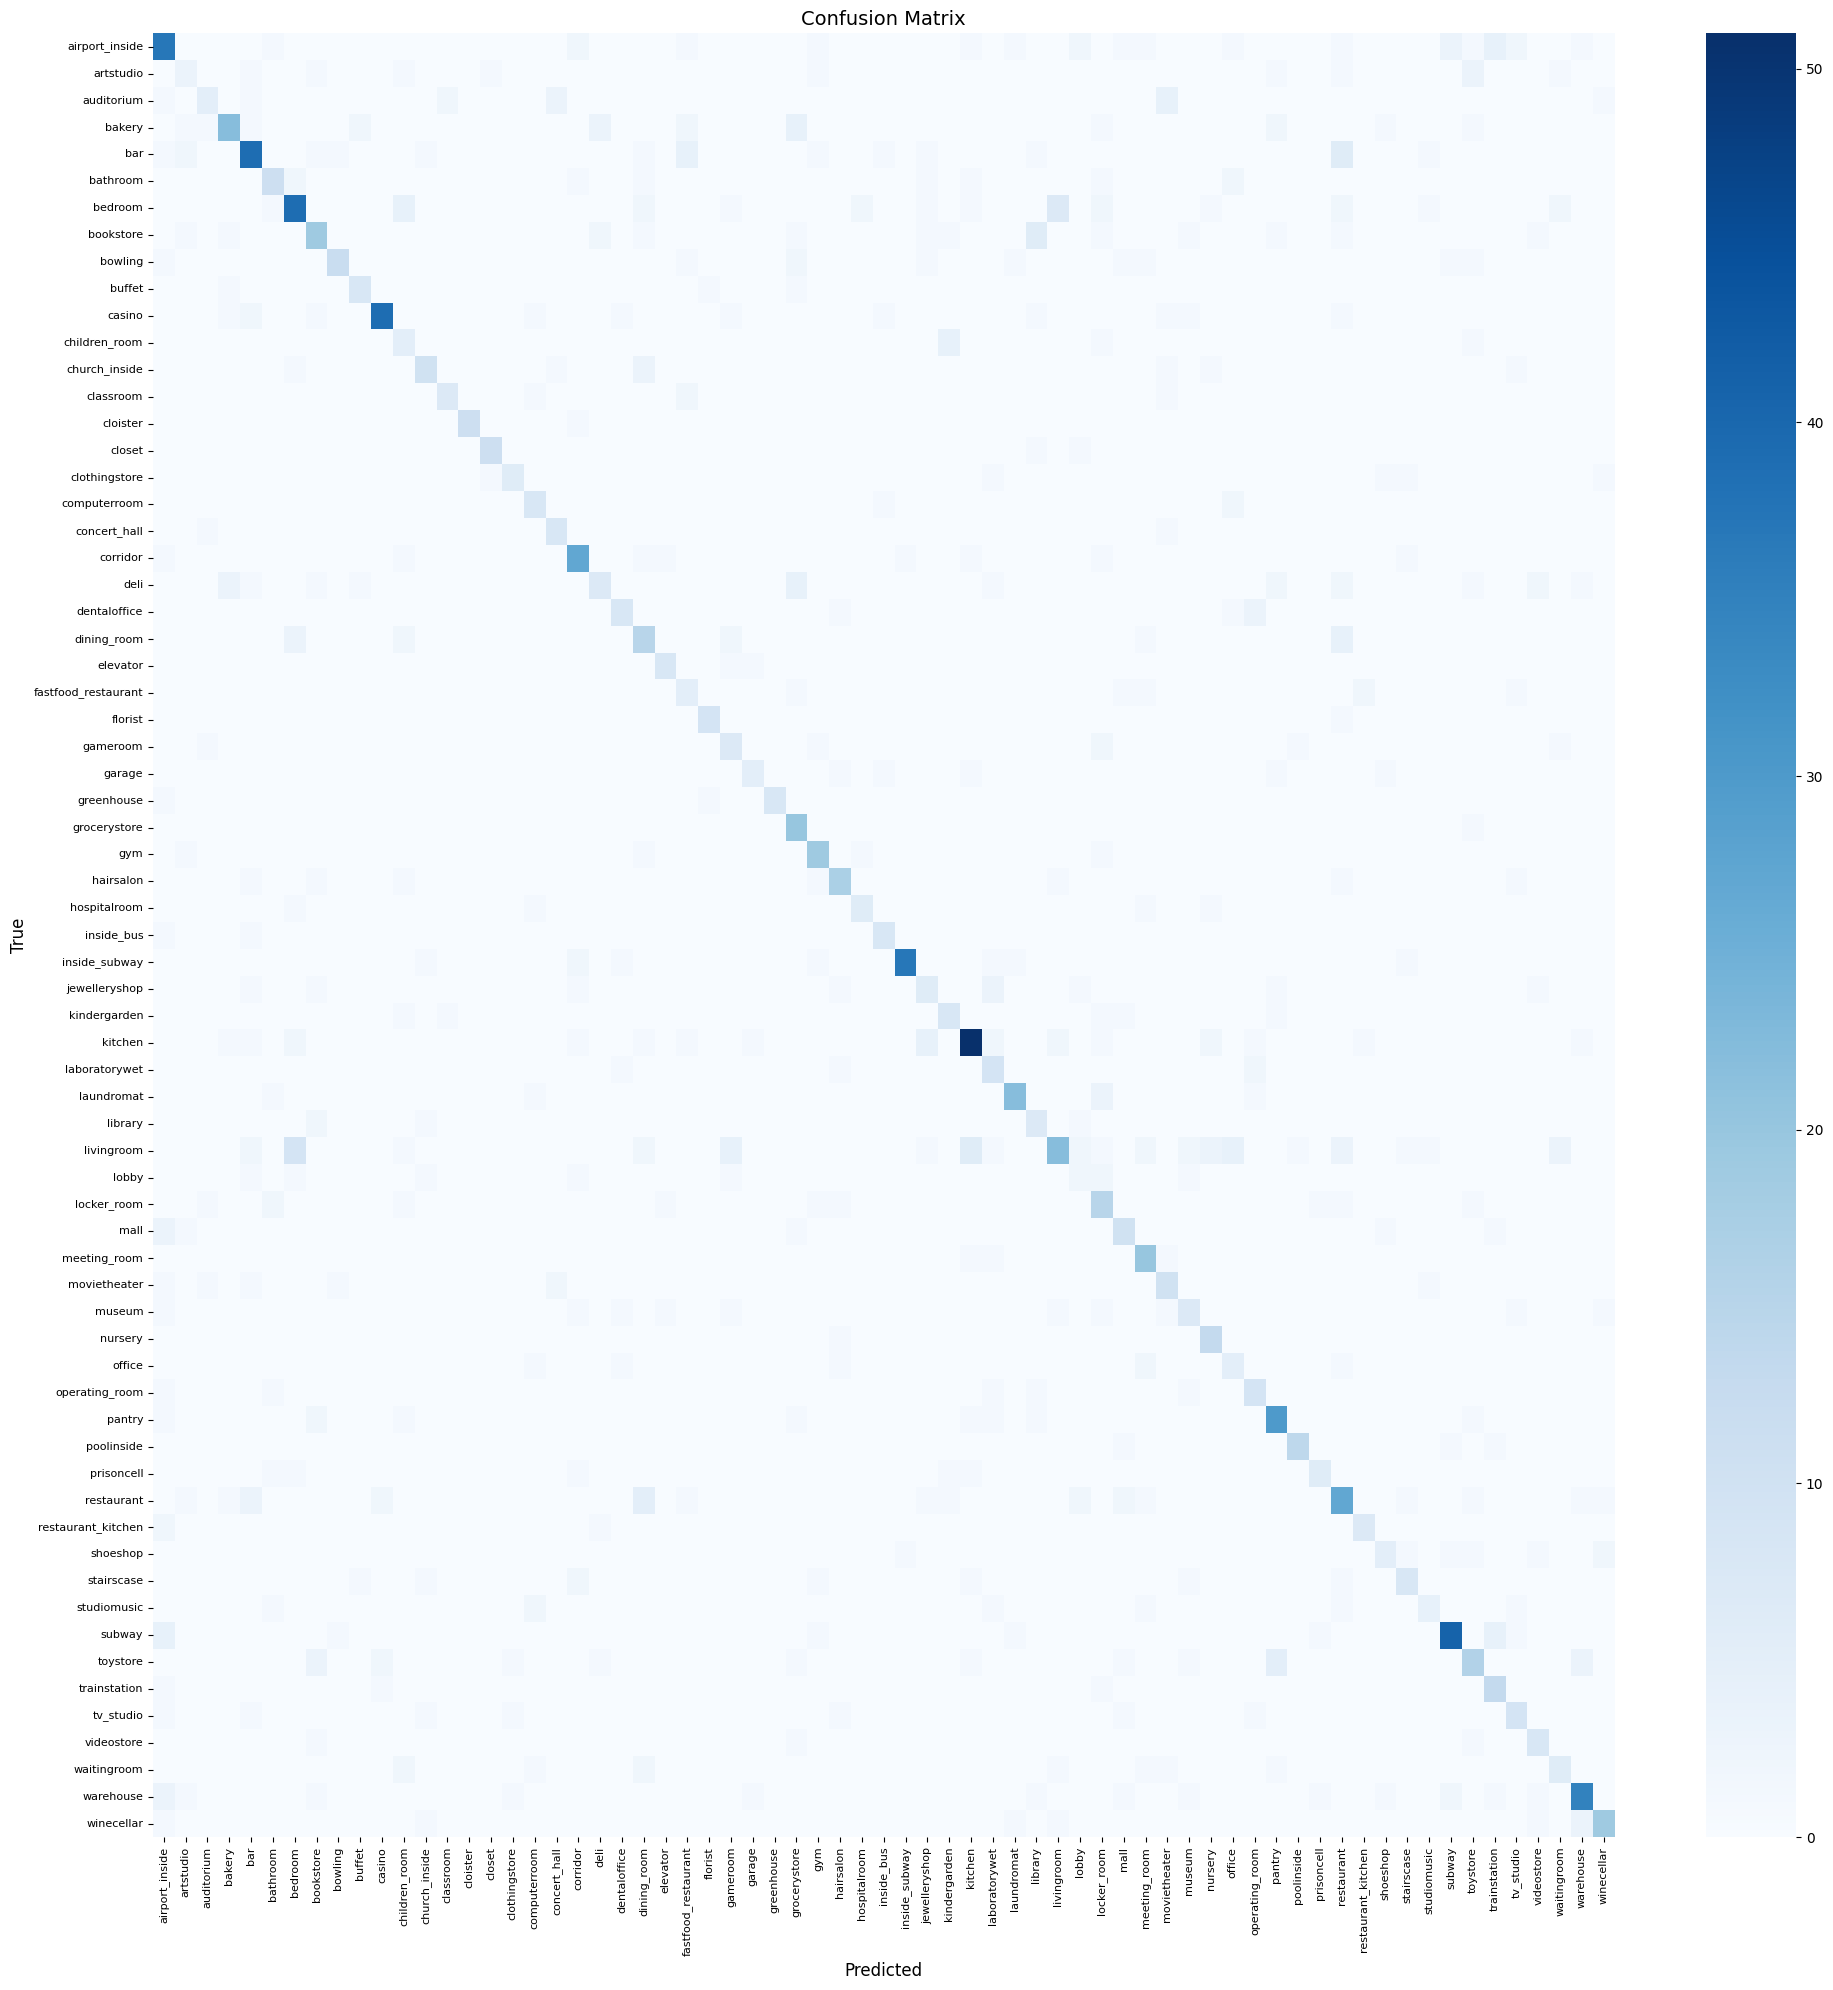

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

# Compute confusion matrix
cm = confusion_matrix(allLabels, allPreds)

# Set figure size to avoid label overlap
plt.figure(figsize=(20, 20))

# Plot the heatmap with no annotations to keep it clean
sns.heatmap(cm, cmap='Blues', xticklabels=classNames, yticklabels=classNames)

plt.xticks(rotation=90, fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.xlabel("Predicted", fontsize=12)
plt.ylabel("True", fontsize=12)
plt.title("Confusion Matrix", fontsize=14)
plt.tight_layout()
plt.show()
